# EDA - Influenza hospitalization data
 
Investigate potential hospitalization data sources for influenza.

## 1. COVID-19 Reported Patient Impact and Hospital Capacity by Facility

[https://healthdata.gov/Hospital/COVID-19-Reported-Patient-Impact-and-Hospital-Capa/anag-cw7u/about_data](https://healthdata.gov/Hospital/COVID-19-Reported-Patient-Impact-and-Hospital-Capa/anag-cw7u/about_data).


**Note**:
"For influenza fields listed in the file, the current HHS guidance marks these fields as optional. As a result, coverage of these elements are varied."


| Column | Description | 
| ------ | ----------- |
| total_patients_hospitalized_confirmed_influenza_7_day_avg | [FAQ - 33] Average number of patients (all ages) currently hospitalized in an inpatient bed who have laboratory-confirmed influenza. Including those in observation beds reported in the 7-day period. | 
| total_patients_hospitalized_confirmed_influenza_7_day_sum | [FAQ - 33] Sum of reports of patients (all ages) currently hospitalized in an inpatient bed who have laboratory-confirmed influenza. Including those in observation beds reported in the 7-day period. | 
| total_patients_hospitalized_confirmed_influenza_7_day_coverage | [FAQ - 33] Number of times in the 7-day period that the facility reported patients (all ages) currently hospitalized in an inpatient bed who have laboratory-confirmed influenza. Including those in observation beds. | 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

In [2]:
hosp_df = pd.read_csv('../../data/raw/COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_Facility_20251026.csv')
hosp_df['collection_week'] = pd.to_datetime(hosp_df['collection_week'])

/local/ipykernel_3538576/3869825040.py:1: DtypeWarning: Columns (0: hospital_pk, 1: ccn) have mixed types. Specify dtype option on import or set low_memory=False.
  hosp_df = pd.read_csv('../../data/raw/COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_Facility_20251026.csv')


<Axes: title={'center': 'total_patients_hospitalized_confirmed_influenza_7_day_sum'}, xlabel='collection_week'>

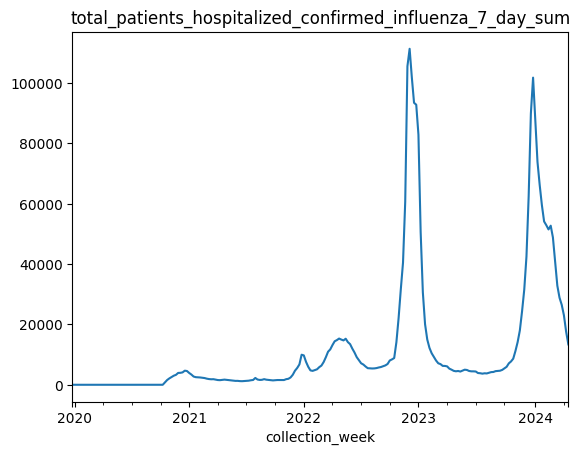

In [4]:
hosp_col = 'total_patients_hospitalized_confirmed_influenza_7_day_sum'
hosp_df[hosp_col] = hosp_df[hosp_col].replace("-999,999", np.nan)
hosp_df[hosp_col] = hosp_df[hosp_col].replace(-999999, np.nan)
hosp_df[hosp_col] = pd.to_numeric(hosp_df[hosp_col], errors="coerce")

hosp_df.groupby('collection_week')[hosp_col].sum().plot(title=hosp_col)

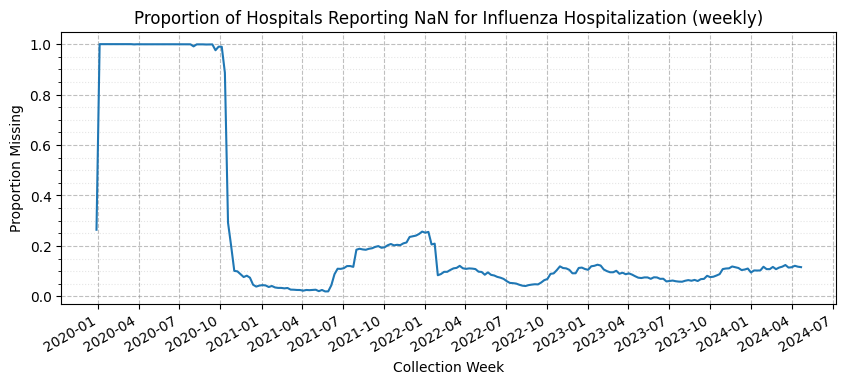

In [5]:
import matplotlib.dates as mdates

nan_count = hosp_df[hosp_df[hosp_col].isna()].groupby('collection_week').size().reset_index(name='nan_count')
hosp_count = hosp_df.groupby('collection_week').size().reset_index(name='hosp_count')

prop_df = nan_count.merge(hosp_count, on='collection_week')
prop_df['prop'] = prop_df['nan_count'] / prop_df['hosp_count']
prop_df['collection_week'] = pd.to_datetime(prop_df['collection_week'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(prop_df['collection_week'], prop_df['prop'])

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()

ax.set_xlabel('Collection Week')
ax.set_ylabel('Proportion Missing')
ax.set_title('Proportion of Hospitals Reporting NaN for Influenza Hospitalization (weekly)')

ax.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.5)
ax.grid(True, which='minor', axis='both', linestyle=':', color='gray', alpha=0.2)
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

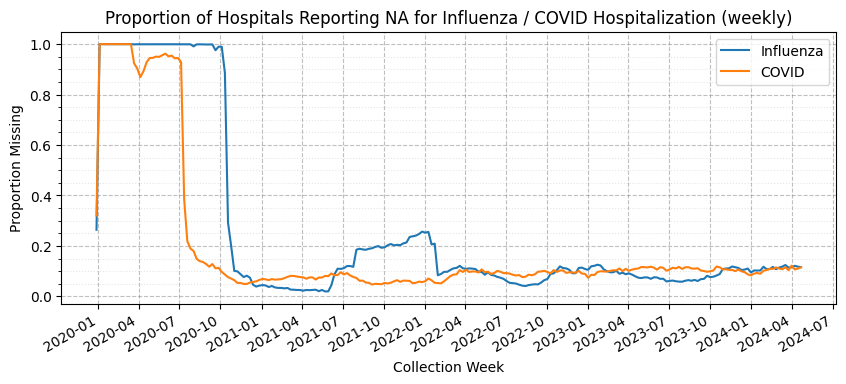

In [7]:
covid_col = 'total_adult_patients_hospitalized_confirmed_covid_7_day_sum'

hosp_df[covid_col] = hosp_df[covid_col].replace("-999,999", np.nan)
hosp_df[covid_col] = hosp_df[covid_col].replace(-999999, np.nan)
hosp_df[covid_col] = pd.to_numeric(hosp_df[covid_col], errors="coerce")


nan_count = hosp_df[hosp_df[covid_col].isna()].groupby('collection_week').size().reset_index(name='nan_count')
hosp_count = hosp_df.groupby('collection_week').size().reset_index(name='hosp_count')

prop_covid_df = nan_count.merge(hosp_count, on='collection_week')
prop_covid_df['prop'] = prop_covid_df['nan_count'] / prop_covid_df['hosp_count']
prop_covid_df['collection_week'] = pd.to_datetime(prop_covid_df['collection_week'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(prop_df['collection_week'], prop_df['prop'], label='Influenza')
ax.plot(prop_covid_df['collection_week'], prop_covid_df['prop'], label='COVID')
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()

ax.set_xlabel('Collection Week')
ax.set_ylabel('Proportion Missing')
ax.set_title('Proportion of Hospitals Reporting NA for Influenza / COVID Hospitalization (weekly)')

ax.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.5)
ax.grid(True, which='minor', axis='both', linestyle=':', color='gray', alpha=0.2)
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

## Seasons

| Season | Start | End |
| ------ | ----- | --- | 
| 2021-22| ?1 of 2022 | ?25 of 2022| 
| 2022-23| ?40 of 2022 | ?18 of 2023| 
| 2023-24| epiweek 41 of 2023 | epiweek  15 of 2024|
| 2024-25| epiweek 47 of 2024 | epiweek 22 of 2025|

** This dataset does not have data for the 2024-25 season. There is voluntary data somewhere [here](https://www.cdc.gov/covid/php/surveillance/index.html#cdc_survey_profile_surveys_used-additional-covid-19-data-and-visualizations) but probably has bad coverage for flu.

In [74]:
from epiweeks import Week

print("==============")
print("2021-22 season")
print(Week(2022, 2).startdate())
print(Week(2022, 25).startdate())

print("==============")
print("2022-23 season:")
print(Week(2022, 40).startdate())
print(Week(2023, 18).startdate())

print("==============")
print("2023-24 season:")
print(Week(2023, 41).startdate())
print(Week(2024, 15).startdate())


2021-22 season
2022-01-09
2022-06-19
2022-23 season:
2022-10-02
2023-04-30
2023-24 season:
2023-10-08
2024-04-07


In [76]:
print('2022-01-09' in hosp_df['collection_week'].unique())
print('2022-06-19' in hosp_df['collection_week'].unique())

print('2022-10-02' in hosp_df['collection_week'].unique())
print('2023-04-30' in hosp_df['collection_week'].unique())

print('2023-10-08' in hosp_df['collection_week'].unique())
print('2024-04-07' in hosp_df['collection_week'].unique())

True
True
True
True
True
True


## 2. Weekly Hospital Respiratory Data (HRD) Metrics by Jurisdiction, National Healthcare Safety Network (NHSN) (Preliminary)


https://data.cdc.gov/Public-Health-Surveillance/Weekly-Hospital-Respiratory-Data-HRD-Metrics-by-Ju/mpgq-jmmr/about_data

In [82]:
state_hosp_df = pd.read_csv("../../data/raw/Weekly_Hospital_Respiratory_Data_(HRD)_Metrics_by_Jurisdiction,_National_Healthcare_Safety_Network_(NHSN)_(Preliminary)_20260308.csv")

state_hosp_df["Week Ending Date"] = pd.to_datetime(state_hosp_df["Week Ending Date"])
state_hosp_df.head()

/local/ipykernel_1292440/2917732768.py:1: DtypeWarning: Columns (0: Number of Pediatric Patients Hospitalized with COVID-19, 1: Number of Pedatric Patients Hospitalized with Influenza, 2: Number of Adult Patients Hospitalized with RSV, 3: Number of Pediatric Patients Hospitalized with RSV, 4: Total Patients Hospitalized with RSV, 5: Number of Adult ICU Patients Hospitalized with Influenza, 6: Total ICU Patients Hospitalized with Influenza, 7: Number of Adult ICU Patients Hospitalized with RSV, 8: Total ICU Patients Hospitalized with RSV, 9: Number of Pediatric COVID-19 Admissions, 0-4 years, 10: Number of Pediatric COVID-19 Admissions, 5-17 years, 11: Total Pediatric COVID-19 Admissions, 12: Number of Adult COVID-19 Admissions, 50-64 years, 13: Number of Adult COVID-19 Admissions, 65-74 years, 14: Number of Adult COVID-19 Admissions, 75+ years, 15: Number of Pediatric Influenza Admissions, 0-4 years, 16: Number of Pediatric Influenza Admissions, 5-17 years, 17: Total Pediatric Influenz

,Week Ending Date,Geographic aggregation,Number of Inpatient Beds,Number of Adult Inpatient Beds,Number of Pediatric Inpatient beds,Number of Inpatient Beds Occupied,Number of Adult Inpatient Beds Occupied,Number of Pediatric Inpatient Beds Occupied,Number of ICU Beds,Number of Adult ICU Beds,...,Absolute Change in the Percent Hospitals Reporting Percent Hospitalized Adult Patients with Influenza in the ICU from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Hospitalized Pediatric Patients with Influenza in the ICU from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Hospitalized Patients with RSV in the ICU from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Hospitalized Adult Patients with RSV in the ICU from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Hospitalized Pediatric Patients with RSV in the ICU from Prior Week,Respiratory Virus Season,Cumulative Seasonal Total Confirmed New COVID-19 Admissions,Cumulative Seasonal Total Confirmed New Influenza Admissions,Cumulative Seasonal Total Confirmed New RSV Admissions,"Cumulative Seasonal Total Confirmed New Respiratory Admissions (COVID-19, Influenza, and RSV)"
0,2021-10-09,AL,"15,602.43","14,288.86",193.71,"11,959.71","11,114.86",125.14,"2,630.86","1,958",...,0.0,0.0,0.0,0.0,0.0,2021-2022,800,13,0,813
1,2021-10-16,AL,"15,596.86","14,281.86",193.86,"11,842.57","10,983",134.43,"2,628.86","1,955.43",...,0.0,0.0,0.0,0.0,0.0,2021-2022,"1,436",18,0,"1,454"
2,2021-10-23,AL,"15,614.14","14,296",196.71,"11,729.71","10,875.57",142.29,"2,617.14","1,943.71",...,0.0,0.0,0.0,0.0,0.0,2021-2022,"1,920",24,0,"1,944"
3,2021-10-30,AL,"15,613.43","14,296.86",195.71,"11,833.43","10,951.57",147.86,"2,615.14","1,942.29",...,0.0,0.0,0.0,0.0,0.0,2021-2022,"2,358",36,0,"2,394"
4,2021-11-06,AL,"15,578.29","14,266.43",187,"11,788.57","10,891.71",161.29,"2,623.86","1,947",...,0.0,0.0,0.0,0.0,0.0,2021-2022,"2,681",45,0,"2,726"


In [83]:
for col in state_hosp_df.columns:
    if "Influenza" in col:
        print(col)

Number of  Adult Patients Hospitalized with Influenza
Number of Pedatric Patients Hospitalized with Influenza
Total Patients Hospitalized with Influenza
Number of Adult ICU Patients Hospitalized with Influenza
Number of Pediatric ICU Patients Hospitalized with Influenza
Total ICU Patients Hospitalized with Influenza
Number of Pediatric Influenza Admissions, 0-4 years
Number of Pediatric Influenza Admissions, 5-17 years
Total Pediatric Influenza Admissions
Number of Adult Influenza Admissions, 18-49 years
Number of Adult Influenza Admissions, 50-64 years
Number of Adult Influenza Admissions, 65-74 years
Number of Adult Influenza Admissions, 75+ years
Total Adult Influenza Admissions
Number of Influenza Admissions, unknown age
Total Influenza Admissions
Percent Inpatient Beds Occupied by Influenza Patients
Percent ICU Beds Occupied by Influenza Patients
Percent Adult Influenza Admissions
Percent Pediatric Influenza Admissions
Number Hospitals Reporting TotalPatients Hospitalized with Inf

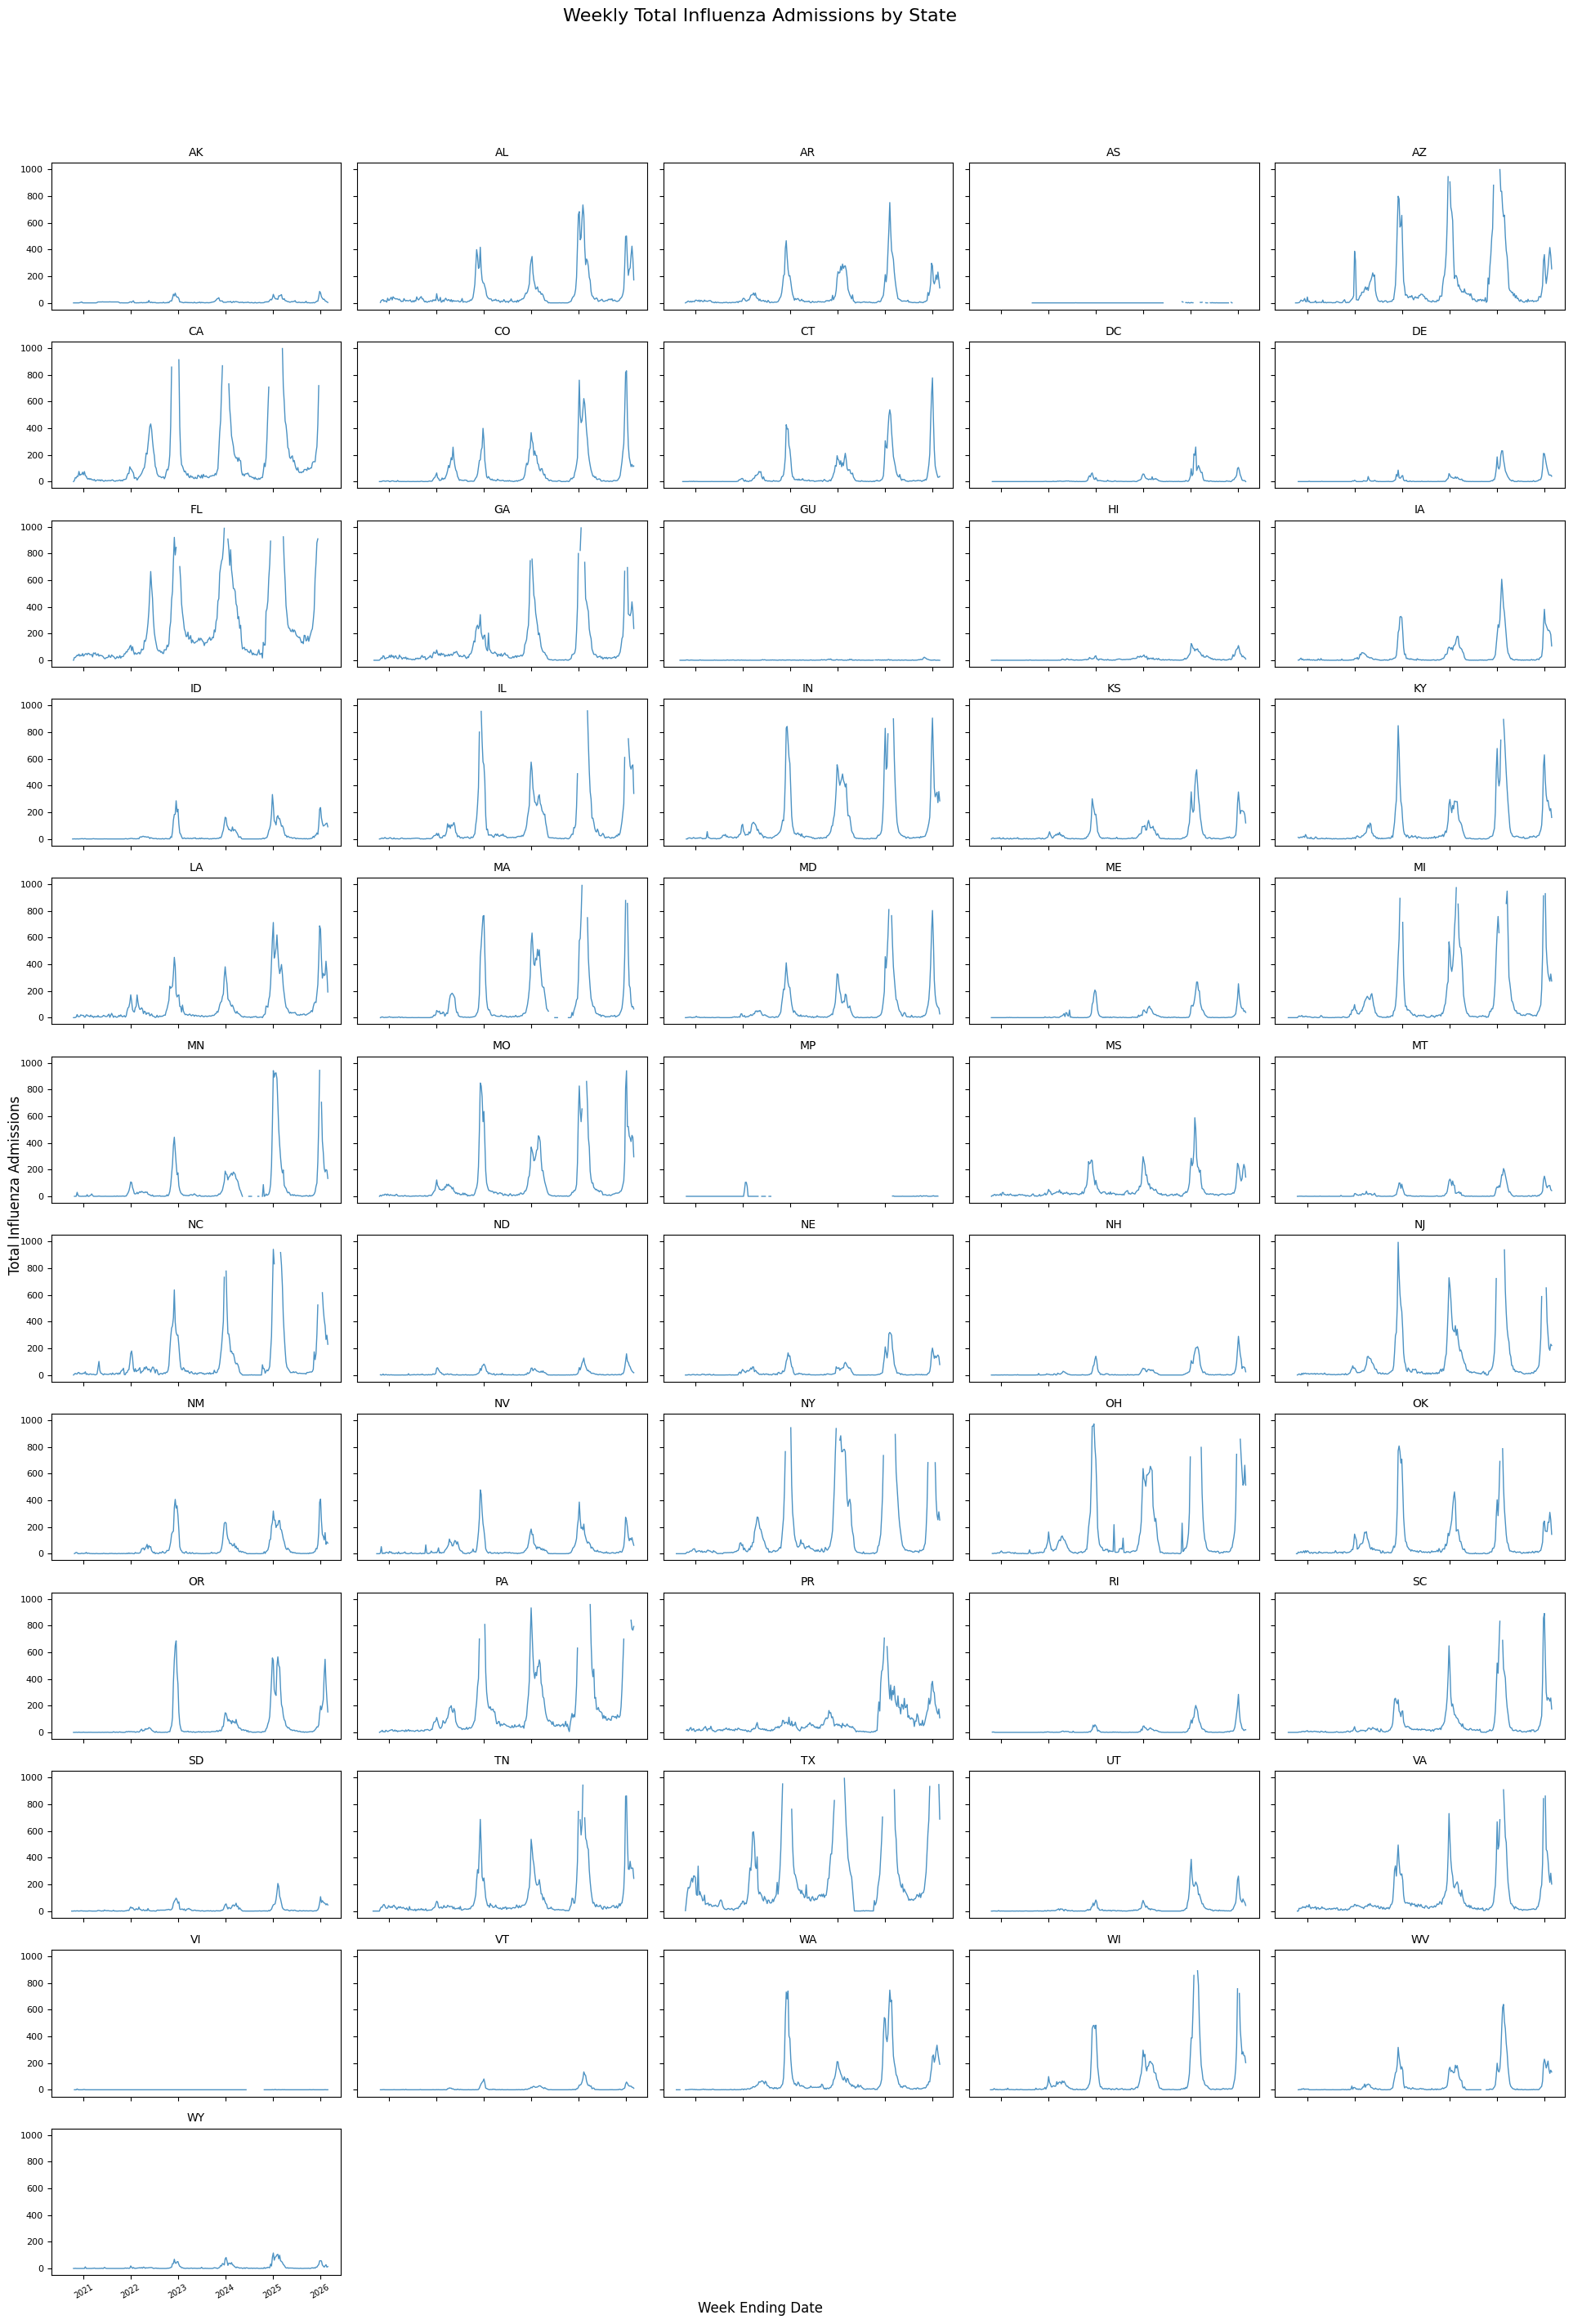

In [94]:
import math

state_hosp_col = "Total Influenza Admissions"
state_hosp_df[state_hosp_col] = pd.to_numeric(state_hosp_df[state_hosp_col], errors="coerce")

# Only use states (exclude "Region" and "USA")
states = sorted([
    s for s in state_hosp_df['Geographic aggregation'].unique()
    if "Region" not in s and s != "USA"
])

n_states = len(states)
ncols = 5
nrows = math.ceil(n_states / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 2.5), sharex=True, sharey=True)

# Flatten axes for easy iteration
axes = axes.flatten()

for idx, state in enumerate(states):
    ax = axes[idx]
    state_df = state_hosp_df[state_hosp_df['Geographic aggregation'] == state].copy()
    # Sort by week ending date for correct plotting
    state_df = state_df.sort_values("Week Ending Date")
    ax.plot(
        state_df["Week Ending Date"],
        state_df[state_hosp_col].astype(float),
        label=state,
        alpha=0.8,
        linewidth=1,
        color="tab:blue"
    )
    ax.set_title(state, fontsize=10)
    ax.tick_params(axis='x', labelrotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)

# Hide any unused subplots if states % ncols != 0
for idx in range(len(states), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(f"Weekly {state_hosp_col} by State", fontsize=16)
fig.text(0.5, 0.04, "Week Ending Date", ha='center', fontsize=12)
fig.text(0.04, 0.5, state_hosp_col, va='center', rotation='vertical', fontsize=12)
plt.tight_layout(rect=[0.04, 0.04, 1, 0.94])
plt.show()
